Sharpe Ratio      0.673642
Sortino Ratio     0.654530
Omega Ratio       1.133683
Portfolio Beta    0.963403
Treynor Ratio     0.138385
Jensen Alpha      0.041361
dtype: float64
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                     GS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4316.04
Distribution:                  Normal   AIC:                           8640.08
Method:            Maximum Likelihood   BIC:                           8662.98
                                        No. Observations:                 2263
Date:                Sun, Apr 27 2025   Df Residuals:                     2262
Time:                        22:52:09   Df Model:                            1
                                 Mean Model                                
                 coef    std err    

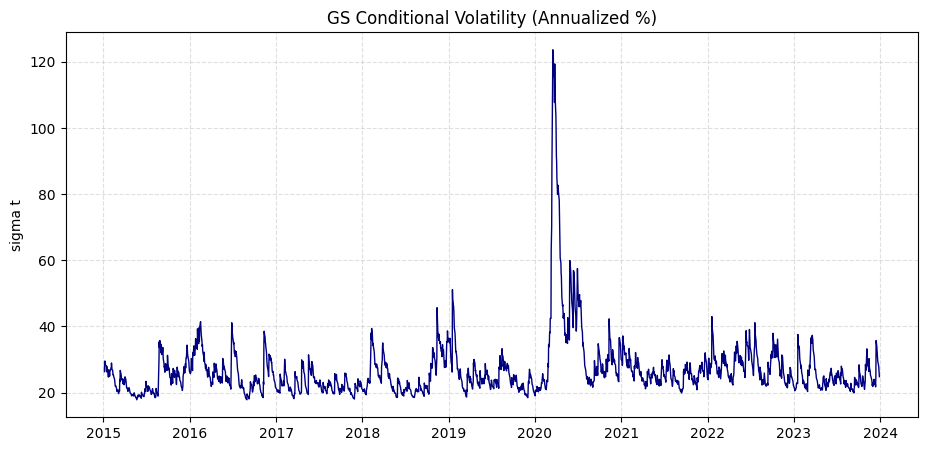


Ljung-Box on std residuals
      lb_stat  lb_pvalue
10  14.101183   0.168426
20  17.895858   0.594269

Ljung-Box on squared std residuals
      lb_stat  lb_pvalue
10   8.353883   0.594313
20  10.502844   0.958111


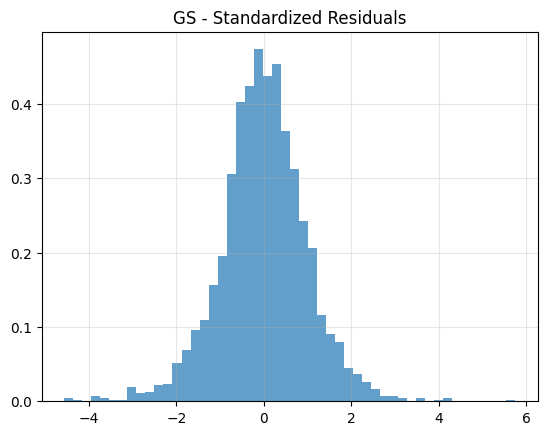

               VaR_95     ES_95
Historical   0.017700  0.029234
RiskMetrics  0.013341  0.016730
EVT (POT)    0.044435  0.062656


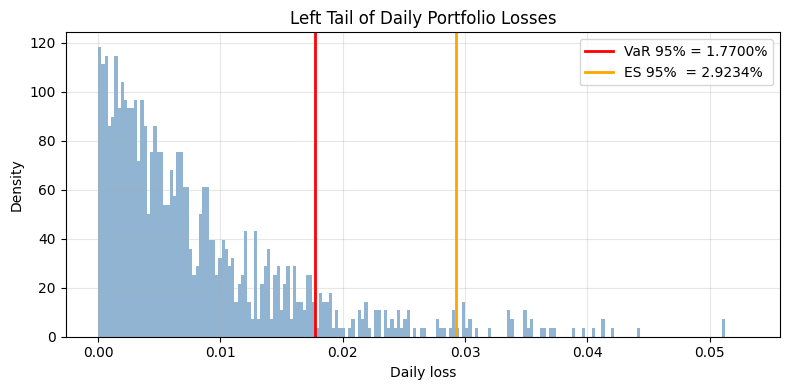


GARCH(1,1)
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                     GS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4316.04
Distribution:                  Normal   AIC:                           8640.08
Method:            Maximum Likelihood   BIC:                           8662.98
                                        No. Observations:                 2263
Date:                Sun, Apr 27 2025   Df Residuals:                     2262
Time:                        22:52:09   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0583  3.210e-02      1.816  6.94

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import yfinance as yf
from arch import arch_model
from scipy.stats import norm, genpareto

#1. Performance Metrics for Portfolio

#a. Select 4 stocks from different sectors and form an equal-weighted portfolio.

TICKERS = [
    "AAPL", #Technology
    "XOM", #Energy
    "JNJ", #Healthcare
    "GS", #Finance
]

weights = pd.Series(1 / len(TICKERS), index=TICKERS)

market_index = "^GSPC"

#b. Download daily price data from Jan 1, 2015 to Jan 1, 2024.

START = "2015-01-01"
END = "2024-01-01"

raw = yf.download(TICKERS + [market_index], start=START, end=END,
                  auto_adjust=False, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw.xs("Adj Close", level=0, axis=1)
else:                       # one ticker only
    prices = raw["Adj Close"]

prices = prices.dropna()

ret = prices.pct_change().dropna()

port_ret = ret[TICKERS].mean(axis=1)

mkt_ret = ret[market_index]

#c. Calculate daily returns and estimate: Sharpe ratio, Sortino ratio,
#Omega ratio, Treynor ratio, and Jensen's Alpha.

rf_annual = 0.015
trading_days =  252
rf_daily = rf_annual / trading_days

def sharpe(r):
  excess = r - rf_daily
  return np.sqrt(trading_days) * excess.mean() / excess.std()

def sortino(r):
  excess = r - rf_daily
  downside = excess[excess < 0]
  dd = np.sqrt((downside**2).mean())
  return np.sqrt(trading_days) * excess.mean() / dd

def omega(r):
  excess = r - rf_daily
  gain = excess[excess > 0].sum()
  loss = -excess[excess < 0].sum()
  return np.inf if loss==0 else gain / loss

def beta(r, m):
  return np.cov(r, m)[0, 1] / m.var()

def treynor(r, m):
  b = beta(r, m)
  return trading_days * (r.mean() - rf_daily) / b

def jensen_alpha(r, m):
  b = beta(r, m)
  alpha = r - (rf_daily + b * (m -rf_daily))
  return trading_days * alpha.mean()

metrics = pd.Series({
    "Sharpe Ratio"   : sharpe(port_ret),
    "Sortino Ratio"  : sortino(port_ret),
    "Omega Ratio"    : omega(port_ret),
    "Portfolio Beta" : beta(port_ret, mkt_ret),
    "Treynor Ratio"  : treynor(port_ret, mkt_ret),
    "Jensen Alpha"   : jensen_alpha(port_ret, mkt_ret)
})

print(metrics)

#2. Estimating and Interpreting GARCH(1,1)

#a. Pick one of the portfolio stocks and estimate a GARCH(1,1) model on its
#return series.

gs_price = (yf.download("GS", start=START, end=END, progress=False,
                        auto_adjust=True)["Close"]).dropna()

gs_ret = 100 * (gs_price.pct_change().dropna())

am = arch_model(gs_ret, mean="constant", vol="GARCH", p=1, q=1, dist="normal")
res = am.fit(update_freq=0, disp="off")

print(res.summary())

#b. Plot the conditional volatiltiy over time.

cond_vol_daily = res.conditional_volatility
cond_vol_ann = cond_vol_daily * np.sqrt(trading_days)

plt.figure(figsize=(11,5))
plt.plot(cond_vol_ann, lw=1, color="navy")
plt.title("GS Conditional Volatility (Annualized %)")
plt.ylabel("sigma t")
plt.grid(alpha=0.4, ls="--")
plt.show()


#c. Interpret the persistence paramter and comment on whether the volatiltiy is
#mean-reverting.

#alpha = 0.0876, beta = 0.8658 => alpha + beta = 0.954
#This is the fraction of yesterday's conditional variance that carries into
#today's forecast. Each day the deviation from the long-run level is multiplied
#by 0.954. At this level, GS's volatility is highly persistent but still
#mean-reverting, as alpha+beta<0.


#d. Run diagnostics: are residuals standardized? Any evidence of remaining ARCH
#effects?

std_resid = res.resid / res.conditional_volatility
lb_mean = acorr_ljungbox(std_resid, lags=[10,20], return_df=True)
lb_arch = acorr_ljungbox(std_resid**2, lags=[10,20], return_df=True)

print("\nLjung-Box on std residuals")
print(lb_mean)

print("\nLjung-Box on squared std residuals")
print(lb_arch)

plt.hist(std_resid, bins=50, density=True, alpha=0.7)
plt.title("GS - Standardized Residuals")
plt.grid(alpha=0.3)
plt.show()

#The distribution is centered at 0, but has slightly heavy tails.
#GARCH(1,1) has absorbed most volaility clustering, as the Ljung-Box has p>0.5.
#GARCH(1,1) is adequate.

#3. Estimating the VaR and ES

#a. Compute VaR and ES at 95% confidence using:

ALPHA = 0.05
loss = -port_ret

#Historical Quantile Method

VaR_hist = np.quantile(loss, 1 - ALPHA)
ES_hist = loss[loss >= VaR_hist].mean()

#RiskMetrics

lam = 0.94
sigma2 = np.empty_like(port_ret)
sigma2[0] = port_ret.iloc[0]**2
for t in range(1, len(port_ret)):
  sigma2[t] = lam * sigma2[t-1] + (1 - lam) * port_ret.iloc[t-1]**2

sigma_t = np.sqrt(sigma2[-1])
z95 = norm.ppf(1 - ALPHA)
VaR_rm = z95 * sigma_t
ES_rm = (norm.pdf(z95) / ALPHA) * sigma_t

#EVT

u = np.quantile(loss, 0.90)
exceed = loss[loss > u] - u

xi, loc, beta = genpareto.fit(exceed, floc=0)
n = len(loss)
nu = len(exceed)

VaR_evt = u + (beta/xi) * (((ALPHA)**(-xi) - 1))
ES_evt = (VaR_evt + beta - xi * u) / (1-xi)

results = pd.DataFrame({
    "VaR_95": [VaR_hist, VaR_rm, VaR_evt],
    "ES_95": [ES_hist, ES_rm, ES_evt]
}, index=["Historical", "RiskMetrics", "EVT (POT)"])

print(results)

#b. Visualize the left tail of the return distribution and annotate the VaR and
#ES thresholds.

VaR = np.quantile(loss, 1 - ALPHA)
ES = loss[loss >= VaR].mean()

plt.figure(figsize=(8,4))
plt.hist(loss, bins=200, density=True, color="steelblue", alpha=0.6, range=(0, VaR*3))

plt.axvline(VaR, color="red",   lw=2, label=f"VaR 95% = {VaR:.4%}")
plt.axvline(ES,  color="orange",lw=2, label=f"ES 95%  = {ES:.4%}")

plt.title("Left Tail of Daily Portfolio Losses")
plt.xlabel("Daily loss")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#c. Comment on how the three estimates differ and what this suggests about the
#tail behavior of the portfolio.

#RiskMetrics sits the lowest, as it assumes conditional normality. The fact
#that it delivers the smallest numbers means the normal model places very litte
#probability mass beyond 2 sigma. It is underweighting extreme losses.

#Historical falls in the middle - it makes no distributional assumption.
#It tends to understate risk, but captures fal tails better than the normal
#distribution. It just sorts the daily observations and picks the 5-percentile.

#EVT is far higher. This is statistical evidence of a heavy left tail.
#The jump from 1.77% to 4.44% means teh tail is much fatter than the window
#reveals. Rate events have a higher probability than N suggests.

#We can conclude that losses obey a heavy tailed law. The tail departs from
#normality. It has a lot of tail risk.

#EXTRA CREDIT: Estimate an EGARCH(1,1) model on the same asset as in section 2.
#Comapre it to the basic GARCH regarding model fit and asymmetry in volatility
#in response to shocks.

egarch = arch_model(gs_ret, mean="Constant", vol="EGARCH", p=1, q=1)
egarch_res = egarch.fit(update_freq=0, disp="off")

print("\nGARCH(1,1)")
print(res.summary())

print("\nEGARCH(1,1)")
print(egarch_res.summary())

garch_persist = res.params["alpha[1]"] + res.params["beta[1]"]
egarch_beta = np.abs(egarch_res.params["beta[1]"])

print(f"\nGARCH persistence alpha + beta: {garch_persist:0.3f}")
print(f"EGARCH persistence beta  : {egarch_beta:0.3f}")

def diagnostics(res):
  std_resid = res.resid / res.conditional_volatility
  lb_r = acorr_ljungbox(std_resid, lags=[10,20], return_df=True)
  lb_r2 = acorr_ljungbox(std_resid**2, lags=[10,20], return_df=True)

  return lb_r["lb_pvalue"], lb_r2["lb_pvalue"]

print("\nLjung-Box p-values (std resid):",  *diagnostics(res)[0])
print("Ljung-Box p-values (squared) :",  *diagnostics(res)[1])

print("\nLjung-Box p-values (std resid, EGARCH):", *diagnostics(egarch_res)[0])
print("Ljung-Box p-values (squared, EGARCH) :", *diagnostics(egarch_res)[1])

#EGARCH is not better fitted than GARCH. Both models give high persistence.
#No residual serial correlation remains, both capture the clustering well.
#GARCH(1,1) is already good enough, unless there is meaningful gamma.
